# wa-setpieces: full walkthrough

An end-to-end tour of the `wa-setpieces` package (v0.17.0) against the
bundled sample Opta F24 match (`tests/data/sample_match.json`). It works
through the package roughly in dependency order: load -> extract -> metrics
-> routines/outcomes -> phases/retention/value -> report/rating ->
defending/scouting -> penalties/long throws -> season form -> plotting ->
exporting.

Run this from the repository root (or adjust `MATCH_FILE` below), with the
optional extras installed:

```bash
pip install -e ".[viz,ml,xlsx]"
```

`ml` unlocks xT-based added value, player rating, shot value and
data-driven routine clustering. `viz` unlocks the pitch plots. `xlsx`
unlocks `save_table(..., "*.xlsx")`. Everything else works with the base
install.


In [1]:
from pathlib import Path

import pandas as pd

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

MATCH_FILE = Path("tests/data/sample_match.json")
OUTPUT_DIR = Path("notebook_output")
OUTPUT_DIR.mkdir(exist_ok=True)


## 1. Loading and validating a match

`load_events` reads an F24 export into a `Match`: the raw `matchDetails`
block plus a tidy events `DataFrame` (one row per event, one column per
Opta qualifierId, named `q_<id>`). `validate_events` checks the
provider-neutral event contract every other function assumes, and
`event_capabilities` reports which optional fields this particular source
actually supplies.


In [2]:
from wa_setpieces import event_capabilities, load_events, validate_events

match = load_events(MATCH_FILE)

print(f"{len(match.events)} events")
print("Teams:", match.events["contestantId"].unique().tolist())

validate_events(match.events)  # raises if the contract is broken
event_capabilities(match.events)


1613 events
Teams: ['cxb4hqite921i36gwrezdts7c', 'f2yd0yzt0om6qhks9gbowu1d6']


EventCapabilities(end_locations=True, assist_links=True, player_identity=True, match_identity=False)

In [3]:
match.events.head()


,id,eventId,typeId,periodId,timeMin,timeSec,contestantId,playerId,playerName,outcome,x,y,timeStamp,q_194,q_227,...,q_77,q_276,q_179,q_113,q_25,q_108,q_180,q_185,q_199,q_389,q_86,q_80,q_209,q_302,q_229
0,2904150991,2,32,1,0,0,cxb4hqite921i36gwrezdts7c,NaN,NaN,1,0.0,0.0,2026-02-24T17:48:09.528Z,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2904150989,2,32,1,0,0,f2yd0yzt0om6qhks9gbowu1d6,NaN,NaN,1,0.0,0.0,2026-02-24T17:48:09.528Z,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2904150997,3,1,1,0,0,cxb4hqite921i36gwrezdts7c,arj6wz36r6wr961xynqg4m4lx,F. Cornejo,1,50.0,50.0,2026-02-24T17:48:09.529Z,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2904151025,4,1,1,0,3,cxb4hqite921i36gwrezdts7c,d7d208zfvkuvjaba38rlcjxl,G. Valle,0,28.5,49.9,2026-02-24T17:48:13.443Z,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2904151045,3,2,1,0,8,f2yd0yzt0om6qhks9gbowu1d6,9g05j8p6gyul0zlnx70rffkve,S. Mina,1,29.5,67.5,2026-02-24T17:48:17.914Z,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Extracting set pieces

Each restart type has a dedicated extractor, plus `extract_all` for every
type at once and `tag_set_pieces` to label events in place.


In [4]:
from wa_setpieces import extract_all, extract_corners, tag_set_pieces

corners = extract_corners(match.events)
all_set_pieces = extract_all(match.events)

print("Corners:", len(corners))
for name, df in all_set_pieces.items():
    print(f"  {name}: {len(df)}")

tagged = tag_set_pieces(match.events)
tagged.loc[tagged["set_piece_type"].notna(), "set_piece_type"].value_counts()


Corners: 9
  penalty: 0
  kick_off: 4
  free_kick: 25
  corner: 9
  throw_in: 50
  goal_kick: 12


set_piece_type
throw_in     50
free_kick    25
goal_kick    12
corner        9
kick_off      4
Name: count, dtype: int64

## 3. Team and player metrics, and the all-in-one summary

`team_set_piece_counts`/`player_set_piece_counts` report attempts,
successful attempts (Opta's own `outcome` flag on the restart event) and
success rate. `set_piece_summary` rolls attempts, success rate, shots and
goals into one headline table.


In [5]:
from wa_setpieces import (
    link_set_piece_shots,
    player_set_piece_counts,
    set_piece_goal_summary,
    set_piece_summary,
    team_set_piece_counts,
)

team_set_piece_counts(match.events)


,contestantId,set_piece_type,attempts,successful,success_rate
0,cxb4hqite921i36gwrezdts7c,corner,2,1,0.500
1,cxb4hqite921i36gwrezdts7c,free_kick,12,9,0.750
2,cxb4hqite921i36gwrezdts7c,goal_kick,8,5,0.625
3,cxb4hqite921i36gwrezdts7c,kick_off,1,1,1.000
4,cxb4hqite921i36gwrezdts7c,throw_in,20,16,0.800
5,f2yd0yzt0om6qhks9gbowu1d6,corner,7,1,0.143
6,f2yd0yzt0om6qhks9gbowu1d6,free_kick,13,9,0.692
7,f2yd0yzt0om6qhks9gbowu1d6,goal_kick,4,3,0.750
8,f2yd0yzt0om6qhks9gbowu1d6,kick_off,3,3,1.000
9,f2yd0yzt0om6qhks9gbowu1d6,throw_in,30,27,0.900


In [6]:
player_set_piece_counts(match.events).sort_values("attempts", ascending=False).head(10)


,playerId,playerName,contestantId,set_piece_type,attempts,successful,success_rate
15,9k61c9b8xjgh6jy6tziw11905,P. Velasco,f2yd0yzt0om6qhks9gbowu1d6,throw_in,14,12,0.857
5,6w4sdzr4l7g9efzx6paxvadat,J. Quintero,cxb4hqite921i36gwrezdts7c,throw_in,12,10,0.833
26,czrsu9ep8tzghq0klucpfv6c5,B. Caicedo,f2yd0yzt0om6qhks9gbowu1d6,throw_in,11,10,0.909
31,d7d208zfvkuvjaba38rlcjxl,G. Valle,cxb4hqite921i36gwrezdts7c,goal_kick,8,5,0.625
11,9cjt8bpelefv3ht1kgcw0hlas,J. Caicedo,cxb4hqite921i36gwrezdts7c,throw_in,5,4,0.800
10,7ww4nc2olcox6pyggzepjth0q,R. Silva,f2yd0yzt0om6qhks9gbowu1d6,goal_kick,4,3,0.750
19,c74dqd8wbe059xsmdo2twmec4,S. Vasquez,f2yd0yzt0om6qhks9gbowu1d6,corner,3,1,0.333
35,ecaofku4htx8if4kk2teq1rrp,R. Adé,cxb4hqite921i36gwrezdts7c,free_kick,3,3,1.000
33,dll3x4ua7q15dcb7gbm61jso9,L. Segovia,cxb4hqite921i36gwrezdts7c,throw_in,3,2,0.667
32,dll3x4ua7q15dcb7gbm61jso9,L. Segovia,cxb4hqite921i36gwrezdts7c,free_kick,3,2,0.667


In [7]:
link_set_piece_shots(match.events).head()


,eventId,typeId,outcome,is_goal,contestantId,playerId,playerName,x,y,timeMin,timeSec,set_piece_type,set_piece_event_id
0,21,15,1,False,f2yd0yzt0om6qhks9gbowu1d6,9k61c9b8xjgh6jy6tziw11905,P. Velasco,79.1,80.1,3,10,None,None
1,22,13,1,False,f2yd0yzt0om6qhks9gbowu1d6,9bsreacxxli5mj5npxgu1ht04,G. Rostagno,79.0,51.7,3,13,None,None
2,88,13,1,False,f2yd0yzt0om6qhks9gbowu1d6,c74dqd8wbe059xsmdo2twmec4,S. Vasquez,87.4,27.0,9,32,None,None
3,161,16,1,True,cxb4hqite921i36gwrezdts7c,5fsqlh1yxgjnjj5u0po1sb36d,J. Corozo,88.0,43.6,19,40,None,None
4,249,13,1,False,cxb4hqite921i36gwrezdts7c,4mzyoimsuzfdc7n2m2i8criz9,M. Estrada,92.0,64.0,34,41,None,None


In [8]:
set_piece_goal_summary(match.events)


,contestantId,set_piece_type,goals


In [9]:
set_piece_summary(match.events)


,contestantId,set_piece_type,attempts,successful,success_rate,shots,goals
0,cxb4hqite921i36gwrezdts7c,corner,2,1,0.500,0,0
1,cxb4hqite921i36gwrezdts7c,free_kick,12,9,0.750,0,0
2,cxb4hqite921i36gwrezdts7c,goal_kick,8,5,0.625,0,0
3,cxb4hqite921i36gwrezdts7c,kick_off,1,1,1.000,0,0
4,cxb4hqite921i36gwrezdts7c,throw_in,20,16,0.800,0,0
5,f2yd0yzt0om6qhks9gbowu1d6,corner,7,1,0.143,0,0
6,f2yd0yzt0om6qhks9gbowu1d6,free_kick,13,9,0.692,0,0
7,f2yd0yzt0om6qhks9gbowu1d6,goal_kick,4,3,0.750,0,0
8,f2yd0yzt0om6qhks9gbowu1d6,kick_off,3,3,1.000,0,0
9,f2yd0yzt0om6qhks9gbowu1d6,throw_in,30,27,0.900,0,0


## 4. Delivery locations

For pass-based set pieces (corner, free kick, throw-in, goal kick, kick
off), `delivery_locations` returns start/end pitch coordinates -- the input
to a corner map or throw-in heatmap.


In [10]:
from wa_setpieces import delivery_locations

corner_deliveries = delivery_locations(match.events, "corner")
corner_deliveries.head()


,eventId,contestantId,playerId,playerName,x,y,end_x,end_y,outcome
0,191,f2yd0yzt0om6qhks9gbowu1d6,d6gphu89283pngbaenacu1cr9,R. Jaramillo,99.9,0.2,95.6,39.5,0
1,223,cxb4hqite921i36gwrezdts7c,cebzrizhi195acmaw8c4cku09,A. Tobar,99.5,99.5,93.4,67.9,1
2,404,cxb4hqite921i36gwrezdts7c,cebzrizhi195acmaw8c4cku09,A. Tobar,99.5,99.5,87.6,43.3,0
3,482,f2yd0yzt0om6qhks9gbowu1d6,c9htznfxd2gjo5s3klq2tvlqt,D. Armas,99.5,0.5,91.6,52.6,0
4,610,f2yd0yzt0om6qhks9gbowu1d6,c74dqd8wbe059xsmdo2twmec4,S. Vasquez,99.4,99.9,96.2,58.3,0


## 5. Routines: taxonomy, delivery technique, target, and clusters

`restart_routines` describes *how* a restart was taken: distance,
direction, a rule-based routine taxonomy, and (for corners/free kicks)
`delivery_technique` (`inswinger`/`outswinger`, from Opta qualifiers
223/224) and `post_target` (`near_post`/`far_post`/`central`).
`analyze_routines` aggregates that into team/taker tactical profiles.


In [11]:
from wa_setpieces import analyze_routines, restart_routines, routine_summary

corner_routines = restart_routines(match.events, "corner")
corner_routines[
    ["playerName", "delivery_technique", "post_target", "routine_type", "distance"]
].head(10)


,playerName,delivery_technique,post_target,routine_type,distance
0,R. Jaramillo,inswinger,near_post,central_six_yard,39.534542
1,A. Tobar,NaN,near_post,penalty_area,32.183381
2,A. Tobar,inswinger,central,penalty_area,57.446062
3,D. Armas,outswinger,central,central_six_yard,52.695541
4,S. Vasquez,inswinger,near_post,central_six_yard,41.722895
5,S. Vasquez,inswinger,near_post,central_six_yard,38.568381
6,S. Vasquez,NaN,near_post,short,10.031949
7,P. Velasco,outswinger,near_post,central_six_yard,40.230461
8,V. Burgoa,outswinger,far_post,central_six_yard,58.174307


In [12]:
routine_analysis = analyze_routines(match.events, "corner", min_taker_attempts=1)
routine_analysis.summary


,contestantId,routine_type,attempts,successful,retained,shots,goals,avg_distance,avg_progression,usage_share,success_rate,retention_rate,shot_rate
0,cxb4hqite921i36gwrezdts7c,penalty_area,2,1,1,0,0,44.81,-9.00,1.000,0.5,0.500,0.0
1,f2yd0yzt0om6qhks9gbowu1d6,central_six_yard,6,0,2,0,0,45.15,-4.63,0.857,0.0,0.333,0.0
2,f2yd0yzt0om6qhks9gbowu1d6,short,1,1,1,0,0,10.03,-4.00,0.143,1.0,1.000,0.0


In [13]:
routine_analysis.team_profiles


,contestantId,set_piece_type,attempts,routine_families,distinct_patterns,most_used_routine,most_used_pattern,top_pattern_share,routine_diversity,success_rate,retention_rate,shot_rate,goal_rate,avg_distance_m,avg_progression
0,cxb4hqite921i36gwrezdts7c,corner,2,1,1,penalty_area,penalty_area|right|penalty_area,1.000,0.000,0.500,0.500,0.0,0.0,31.31,-9.00
1,f2yd0yzt0om6qhks9gbowu1d6,corner,7,2,4,central_six_yard,central_six_yard|right|six_yard_box,0.429,0.921,0.143,0.429,0.0,0.0,27.60,-4.54


As a data-driven alternative to the fixed taxonomy, `cluster_routines`
groups deliveries by geometric similarity (k-means, needs the `ml`
extra) instead of hand-written rules.


In [14]:
from wa_setpieces import cluster_routines, cluster_summary

clustered = cluster_routines(match.events, "corner", n_clusters=3)
if clustered is not None:
    display(clustered[["playerName", "cluster", "x", "y", "end_x", "end_y"]].head(10))
    display(cluster_summary(clustered))
else:
    print("cluster_routines needs the ml extra (pip install \"wa-setpieces[ml]\") "
          "and enough deliveries for the requested number of clusters.")


,playerName,cluster,x,y,end_x,end_y
0,R. Jaramillo,1,99.9,0.2,95.6,39.5
1,A. Tobar,0,99.5,99.5,93.4,67.9
2,A. Tobar,0,99.5,99.5,87.6,43.3
3,D. Armas,1,99.5,0.5,91.6,52.6
4,S. Vasquez,0,99.4,99.9,96.2,58.3
5,S. Vasquez,0,99.6,99.5,96.0,61.1
6,S. Vasquez,2,99.7,99.1,95.7,89.9
7,P. Velasco,1,99.6,0.7,95.3,40.7
8,V. Burgoa,0,99.5,99.5,95.0,41.5


,cluster,cluster_label,attempts,successful,shots,goals,avg_distance,avg_progression,success_rate,shot_rate
0,0,"long, backward, right",5,1,0,0,45.62,-5.86,0.2,0.0
1,1,"long, backward, left",3,0,0,0,44.15,-5.50,0.0,0.0
2,2,"short, backward, right",1,1,0,0,10.03,-4.00,1.0,0.0


## 6. Outcomes and aerial duels

`delivery_outcomes` classifies each corner/free-kick delivery into one
discrete `delivery_outcome` (for a shot-map-style scatter). When that
outcome is a contested header, `aerial_duel_summary` reports who actually
won it.


In [15]:
from wa_setpieces import aerial_duel_summary, delivery_outcomes, outcome_summary

corner_outcomes = delivery_outcomes(match.events, "corner")
corner_outcomes[["playerName", "delivery_outcome", "x", "y", "is_goal"]].head(10)


,playerName,delivery_outcome,x,y,is_goal
0,R. Jaramillo,first_touch_lost,91.7,28.2,False
1,A. Tobar,first_touch_won,99.3,74.8,False
2,A. Tobar,first_touch_lost,91.1,50.5,False
3,D. Armas,first_touch_lost,88.3,42.2,False
4,S. Vasquez,second_phase_shot,91.1,67.3,False
5,S. Vasquez,aerial_duel,96.0,61.1,False
6,S. Vasquez,short_corner,95.7,89.9,False
7,P. Velasco,second_phase_shot,84.5,46.7,False
8,V. Burgoa,first_touch_lost,90.8,49.4,False


In [16]:
outcome_summary(match.events, "corner")


,contestantId,delivery_outcome,count
0,cxb4hqite921i36gwrezdts7c,first_touch_lost,1
1,cxb4hqite921i36gwrezdts7c,first_touch_won,1
2,f2yd0yzt0om6qhks9gbowu1d6,aerial_duel,1
3,f2yd0yzt0om6qhks9gbowu1d6,first_touch_lost,3
4,f2yd0yzt0om6qhks9gbowu1d6,second_phase_shot,2
5,f2yd0yzt0om6qhks9gbowu1d6,short_corner,1


In [17]:
aerial_team_summary, aerial_player_summary = aerial_duel_summary(match.events, "corner")
display(aerial_team_summary)
display(aerial_player_summary)


,contestantId,duels_involved,duels_won,win_rate
0,cxb4hqite921i36gwrezdts7c,1,1,1.0
1,f2yd0yzt0om6qhks9gbowu1d6,1,0,0.0


,playerId,playerName,contestantId,duels_won
0,eu1htvf3chz0kcrl5paflxzv9,Deyverson,cxb4hqite921i36gwrezdts7c,1


## 7. Second phases and retention

`second_phases` classifies what happened right after a delivery
(cleared / first-phase shot / second-phase shot). `retention_detail`
checks whether the attacking team is still in possession ~8 seconds later.


In [18]:
from wa_setpieces import retention_detail, retention_rate, second_phases

phases = second_phases(match.events, "corner")
phases[["cleared_immediately", "direct_shot", "second_phase_shot"]].sum()


cleared_immediately    0
direct_shot            0
second_phase_shot      2
dtype: int64

In [19]:
retention_detail(match.events, "corner").head()


,eventId,contestantId,playerId,playerName,outcome,retained
0,191,f2yd0yzt0om6qhks9gbowu1d6,d6gphu89283pngbaenacu1cr9,R. Jaramillo,0,False
1,223,cxb4hqite921i36gwrezdts7c,cebzrizhi195acmaw8c4cku09,A. Tobar,1,True
2,404,cxb4hqite921i36gwrezdts7c,cebzrizhi195acmaw8c4cku09,A. Tobar,0,False
3,482,f2yd0yzt0om6qhks9gbowu1d6,c9htznfxd2gjo5s3klq2tvlqt,D. Armas,0,False
4,610,f2yd0yzt0om6qhks9gbowu1d6,c74dqd8wbe059xsmdo2twmec4,S. Vasquez,0,True


In [20]:
retention_rate(match.events, "corner")


,contestantId,deliveries,retained,retention_rate
0,cxb4hqite921i36gwrezdts7c,2,1,0.500
1,f2yd0yzt0om6qhks9gbowu1d6,7,3,0.429


## 8. Expected threat (xT) and added value

`XTModel.fit` learns a possession-value grid from this match's own event
data (a real deployment fits it on a full season instead -- one match is
too little signal, see the module docstring). `added_value` scores every
delivery by the xT gained plus the quality/outcome of any resulting shot.


In [21]:
from wa_setpieces import XTModel, set_piece_added_value

model = XTModel.fit(match.events)
value = set_piece_added_value(match.events, "corner", model)
value[["playerName", "delivery_xt_added", "shot_value", "added_value", "is_goal"]].head(10)


,playerName,delivery_xt_added,shot_value,added_value,is_goal
0,R. Jaramillo,0.0,0.0,0.0,False
1,A. Tobar,0.0,0.0,0.0,False
2,A. Tobar,0.0,0.0,0.0,False
3,D. Armas,0.0,0.0,0.0,False
4,S. Vasquez,0.0,0.0,0.0,False
5,S. Vasquez,0.0,0.0,0.0,False
6,S. Vasquez,0.0,0.0,0.0,False
7,P. Velasco,0.0,0.0,0.0,False
8,V. Burgoa,0.0,0.0,0.0,False


## 9. The team report and 0-100 ratings

`corner_report` (via `core.report`) rolls everything above up per team.
`team_rating`/`player_rating` turn a report into a single 0-100 score,
benchmarked against whoever else is in the table -- always rate a full
season/competition, not one match (see the module docstring for why; a
one-match rating below is illustrative only).


In [22]:
from wa_setpieces import corner_report, player_rating, team_rating

report = corner_report(match.events, model=model)
report


,contestantId,attempts,successful,success_rate,second_phases,second_phase_goals,second_phase_rate,retention_rate,total_added_value,avg_added_value,goals
0,cxb4hqite921i36gwrezdts7c,2,1,0.500,0,0,0.000,0.500,0.0,0.0,0
1,f2yd0yzt0om6qhks9gbowu1d6,7,1,0.143,2,0,0.286,0.429,0.0,0.0,0


In [23]:
team_rating(report)


,contestantId,attempts,successful,success_rate,second_phases,second_phase_goals,second_phase_rate,retention_rate,total_added_value,avg_added_value,goals,success_rate_score,avg_added_value_score,retention_rate_score,rating
0,cxb4hqite921i36gwrezdts7c,2,1,0.500,0,0,0.000,0.500,0.0,0.0,0,65.0,50.0,65.0,59.0
1,f2yd0yzt0om6qhks9gbowu1d6,7,1,0.143,2,0,0.286,0.429,0.0,0.0,0,35.0,50.0,35.0,41.0


In [24]:
player_rating(match.events, "corner", model, min_deliveries=1, min_shots=1)


,playerId,playerName,contestantId,deliveries,delivery_score,shots,finishing_score,rating
0,cebzrizhi195acmaw8c4cku09,A. Tobar,cxb4hqite921i36gwrezdts7c,2,63.4,NaN,NaN,63.4
1,c74dqd8wbe059xsmdo2twmec4,S. Vasquez,f2yd0yzt0om6qhks9gbowu1d6,3,57.2,NaN,NaN,57.2
2,9k61c9b8xjgh6jy6tziw11905,P. Velasco,f2yd0yzt0om6qhks9gbowu1d6,1,44.8,NaN,NaN,44.8
3,1ucqsxxm3m3imvujk6av8c0oa,V. Burgoa,f2yd0yzt0om6qhks9gbowu1d6,1,44.8,NaN,NaN,44.8
4,c9htznfxd2gjo5s3klq2tvlqt,D. Armas,f2yd0yzt0om6qhks9gbowu1d6,1,44.8,NaN,NaN,44.8
5,d6gphu89283pngbaenacu1cr9,R. Jaramillo,f2yd0yzt0om6qhks9gbowu1d6,1,44.8,NaN,NaN,44.8


## 10. The whole pipeline in one call

Everything above -- team/player counts, delivery locations, second-phase
detection, retention, added value, the report, the rating, defensive
conceding profiles, routine clusters, aerial-duel record, penalty
placement, and long-throw analysis -- is one function chain most people
want run together. `run_workflow` runs that whole chain for one set-piece
type and hands back every table in one `SetPieceWorkflow`.


In [25]:
from wa_setpieces import run_workflow

workflow = run_workflow(match.events, "corner", model=model)

print("Fields on this SetPieceWorkflow:")
for field in workflow.__dataclass_fields__:
    value = getattr(workflow, field)
    shape = f"{len(value)} rows" if isinstance(value, pd.DataFrame) else type(value).__name__
    print(f"  {field}: {shape}")


Fields on this SetPieceWorkflow:
  set_piece_type: str
  summary: 2 rows
  team_counts: 2 rows
  player_counts: 6 rows
  deliveries: 9 rows
  second_phases: 9 rows
  retention: 9 rows
  added_value: 9 rows
  report: 2 rows
  team_rating: 2 rows
  player_rating: 1 rows
  defensive_summary: 2 rows
  defensive_routine_summary: 3 rows
  defensive_zone_summary: 4 rows
  first_contacts: 9 rows
  routines: 9 rows
  routine_summary: 3 rows
  routine_team_profiles: 2 rows
  routine_taker_profiles: 1 rows
  routine_target_matrix: 4 rows
  routine_clusters: 9 rows
  aerial_duel_team_summary: 2 rows
  aerial_duel_player_summary: 1 rows
  penalty_placement: NoneType
  penalty_taker_summary: NoneType
  long_throw_taker_summary: NoneType
  long_throw_second_phases: NoneType


In [26]:
workflow.defensive_routine_summary


,contestantId,routine_type,attempts_faced,shots_conceded,goals_conceded,shot_rate_conceded
0,cxb4hqite921i36gwrezdts7c,central_six_yard,6,0,0,0.0
1,cxb4hqite921i36gwrezdts7c,short,1,0,0,0.0
2,f2yd0yzt0om6qhks9gbowu1d6,penalty_area,2,0,0,0.0


## 11. Defending and opponent scouting

`core.defending` flips the attacking-team perspective to "what does this
team concede" -- the basis of a pre-match scouting report.


In [27]:
from wa_setpieces import defensive_set_piece_summary, defensive_routine_summary, defensive_zone_summary

defensive_set_piece_summary(match.events)


,contestantId,set_piece_type,matches,attempts_faced,opponent_successful,shots_conceded,goals_conceded,opponent_success_rate,shots_conceded_per_100
0,cxb4hqite921i36gwrezdts7c,corner,1,7,1,0,0,0.143,0.0
1,cxb4hqite921i36gwrezdts7c,free_kick,1,13,9,0,0,0.692,0.0
2,cxb4hqite921i36gwrezdts7c,goal_kick,1,4,3,0,0,0.750,0.0
3,cxb4hqite921i36gwrezdts7c,kick_off,1,3,3,0,0,1.000,0.0
4,cxb4hqite921i36gwrezdts7c,throw_in,1,30,27,0,0,0.900,0.0
5,f2yd0yzt0om6qhks9gbowu1d6,corner,1,2,1,0,0,0.500,0.0
6,f2yd0yzt0om6qhks9gbowu1d6,free_kick,1,12,9,0,0,0.750,0.0
7,f2yd0yzt0om6qhks9gbowu1d6,goal_kick,1,8,5,0,0,0.625,0.0
8,f2yd0yzt0om6qhks9gbowu1d6,kick_off,1,1,1,0,0,1.000,0.0
9,f2yd0yzt0om6qhks9gbowu1d6,throw_in,1,20,16,0,0,0.800,0.0


In [28]:
defensive_zone_summary(match.events, "corner")


,contestantId,destination_zone,attempts_faced,shots_conceded,goals_conceded,shot_rate_conceded
0,cxb4hqite921i36gwrezdts7c,six_yard_box,5,0,0,0.0
1,cxb4hqite921i36gwrezdts7c,penalty_area,1,0,0,0.0
2,cxb4hqite921i36gwrezdts7c,wide_final_third,1,0,0,0.0
3,f2yd0yzt0om6qhks9gbowu1d6,penalty_area,2,0,0,0.0


`opponent_scouting_report_html` turns that into a ready-to-view scouting
report for one opponent.


61,981 characters written to notebook_output/opponent_scouting_report.html


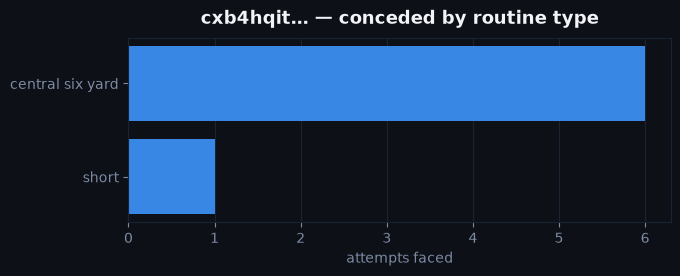

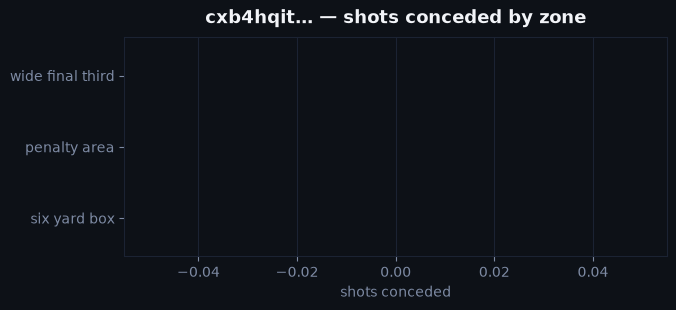

In [29]:
from wa_setpieces import opponent_scouting_report_html

opponent = match.events["contestantId"].unique()[0]
scouting_html = opponent_scouting_report_html(match.events, opponent, set_piece_type="corner")
(OUTPUT_DIR / "opponent_scouting_report.html").write_text(scouting_html, encoding="utf-8")
print(f"{len(scouting_html):,} characters written to "
      f"{OUTPUT_DIR / 'opponent_scouting_report.html'}")


## 12. Penalties and long throws

Two set-piece types get their own dedicated helpers beyond the generic
routine taxonomy: penalty placement zones, and the one throw-in pattern
that plays like a corner (a "long throw").


In [30]:
from wa_setpieces import penalty_placement_detail, penalty_taker_summary

penalties = penalty_placement_detail(match.events)
if len(penalties):
    display(penalties.head())
    display(penalty_taker_summary(penalties))
else:
    print("No penalties in this match.")


No penalties in this match.


In [31]:
from wa_setpieces import long_throw_taker_summary, long_throw_second_phases

long_throw_takers = long_throw_taker_summary(match.events)
long_throw_phases = long_throw_second_phases(match.events)
if len(long_throw_takers):
    display(long_throw_takers)
    display(long_throw_phases)
else:
    print("No long throws detected in this match.")


,playerId,playerName,contestantId,long_throws,share_of_team_throws,retention_rate,shots_created,goals_created
0,9k61c9b8xjgh6jy6tziw11905,P. Velasco,f2yd0yzt0om6qhks9gbowu1d6,7,0.233,0.714,0,0
1,czrsu9ep8tzghq0klucpfv6c5,B. Caicedo,f2yd0yzt0om6qhks9gbowu1d6,6,0.200,0.500,0,0
2,6w4sdzr4l7g9efzx6paxvadat,J. Quintero,cxb4hqite921i36gwrezdts7c,5,0.250,0.200,0,0
3,1utevvu25zcl4h757yegr1n2s,M. Bermúdez,f2yd0yzt0om6qhks9gbowu1d6,1,0.033,1.000,0,0
4,9cjt8bpelefv3ht1kgcw0hlas,J. Caicedo,cxb4hqite921i36gwrezdts7c,1,0.050,0.000,0,0
5,dll3x4ua7q15dcb7gbm61jso9,L. Segovia,cxb4hqite921i36gwrezdts7c,1,0.050,1.000,0,0


,delivery_event_id,set_piece_type,contestant_id,opponent_id,first_contact_event_id,first_contact_team,first_contact_type_id,cleared_immediately,direct_shot,direct_shot_event_id,direct_shot_is_goal,second_phase_shot,second_phase_event_id,second_phase_is_goal,phase_events_n
0,25,throw_in,f2yd0yzt0om6qhks9gbowu1d6,cxb4hqite921i36gwrezdts7c,26,f2yd0yzt0om6qhks9gbowu1d6,1,False,False,None,False,False,None,False,6
1,44,throw_in,cxb4hqite921i36gwrezdts7c,f2yd0yzt0om6qhks9gbowu1d6,45,cxb4hqite921i36gwrezdts7c,61,False,False,None,False,False,None,False,13
2,50,throw_in,cxb4hqite921i36gwrezdts7c,f2yd0yzt0om6qhks9gbowu1d6,51,cxb4hqite921i36gwrezdts7c,44,False,False,None,False,False,None,False,13
3,111,throw_in,cxb4hqite921i36gwrezdts7c,f2yd0yzt0om6qhks9gbowu1d6,120,f2yd0yzt0om6qhks9gbowu1d6,4,False,False,None,False,False,None,False,2
4,127,throw_in,f2yd0yzt0om6qhks9gbowu1d6,cxb4hqite921i36gwrezdts7c,121,cxb4hqite921i36gwrezdts7c,44,False,False,None,False,False,None,False,10
5,131,throw_in,f2yd0yzt0om6qhks9gbowu1d6,cxb4hqite921i36gwrezdts7c,132,f2yd0yzt0om6qhks9gbowu1d6,1,False,False,None,False,False,None,False,11
6,144,throw_in,f2yd0yzt0om6qhks9gbowu1d6,cxb4hqite921i36gwrezdts7c,145,f2yd0yzt0om6qhks9gbowu1d6,1,False,False,None,False,False,None,False,11
7,181,throw_in,f2yd0yzt0om6qhks9gbowu1d6,cxb4hqite921i36gwrezdts7c,182,f2yd0yzt0om6qhks9gbowu1d6,1,False,False,None,False,False,None,False,9
8,187,throw_in,f2yd0yzt0om6qhks9gbowu1d6,cxb4hqite921i36gwrezdts7c,188,f2yd0yzt0om6qhks9gbowu1d6,50,False,False,None,False,False,None,False,4
9,234,throw_in,f2yd0yzt0om6qhks9gbowu1d6,cxb4hqite921i36gwrezdts7c,237,cxb4hqite921i36gwrezdts7c,83,False,False,None,False,False,None,False,7


## 13. Season form (multiple matches)

`SeasonDataset` stacks several match exports and aggregates safely across
them (Opta's `eventId` is only unique *within* one team's stream *per
match*, so naive cross-match joins silently corrupt -- `SeasonDataset`
takes care of this). With more than one match it also computes rolling
attacking and defensive form. This sample repository ships one match, so
the season here is a season of one -- enough to show the shape of the
output, not to draw conclusions from.


In [32]:
from wa_setpieces import SeasonDataset

season = SeasonDataset.from_sources([MATCH_FILE])
season.report("corner", model=model)


,contestantId,attempts,successful,success_rate,second_phases,second_phase_goals,second_phase_rate,retention_rate,total_added_value,avg_added_value,goals,matchId
0,cxb4hqite921i36gwrezdts7c,2,1,0.500,0,0,0.000,0.500,0.0,0.0,0,sample_match
1,f2yd0yzt0om6qhks9gbowu1d6,7,1,0.143,2,0,0.286,0.429,0.0,0.0,0,sample_match


In [33]:
season.rolling_summary(window=1)


,contestantId,set_piece_type,attempts,successful,success_rate,shots,goals,matchId,rolling_attempts,rolling_successful,rolling_shots,rolling_goals,rolling_success_rate
0,cxb4hqite921i36gwrezdts7c,corner,2,1,0.500,0,0,sample_match,2.0,1.0,0.0,0.0,0.500000
1,cxb4hqite921i36gwrezdts7c,free_kick,12,9,0.750,0,0,sample_match,12.0,9.0,0.0,0.0,0.750000
2,cxb4hqite921i36gwrezdts7c,goal_kick,8,5,0.625,0,0,sample_match,8.0,5.0,0.0,0.0,0.625000
3,cxb4hqite921i36gwrezdts7c,kick_off,1,1,1.000,0,0,sample_match,1.0,1.0,0.0,0.0,1.000000
4,cxb4hqite921i36gwrezdts7c,throw_in,20,16,0.800,0,0,sample_match,20.0,16.0,0.0,0.0,0.800000
5,f2yd0yzt0om6qhks9gbowu1d6,corner,7,1,0.143,0,0,sample_match,7.0,1.0,0.0,0.0,0.142857
6,f2yd0yzt0om6qhks9gbowu1d6,free_kick,13,9,0.692,0,0,sample_match,13.0,9.0,0.0,0.0,0.692308
7,f2yd0yzt0om6qhks9gbowu1d6,goal_kick,4,3,0.750,0,0,sample_match,4.0,3.0,0.0,0.0,0.750000
8,f2yd0yzt0om6qhks9gbowu1d6,kick_off,3,3,1.000,0,0,sample_match,3.0,3.0,0.0,0.0,1.000000
9,f2yd0yzt0om6qhks9gbowu1d6,throw_in,30,27,0.900,0,0,sample_match,30.0,27.0,0.0,0.0,0.900000


In [34]:
season.rolling_defensive_summary(window=1)


,contestantId,set_piece_type,matches,attempts_faced,opponent_successful,shots_conceded,goals_conceded,opponent_success_rate,shots_conceded_per_100,matchId,rolling_attempts_faced,rolling_opponent_successful,rolling_shots_conceded,rolling_goals_conceded,rolling_opponent_success_rate,rolling_shots_conceded_per_100
0,cxb4hqite921i36gwrezdts7c,corner,1,7,1,0,0,0.143,0.0,sample_match,7.0,1.0,0.0,0.0,0.143,0.0
1,cxb4hqite921i36gwrezdts7c,free_kick,1,13,9,0,0,0.692,0.0,sample_match,13.0,9.0,0.0,0.0,0.692,0.0
2,cxb4hqite921i36gwrezdts7c,goal_kick,1,4,3,0,0,0.750,0.0,sample_match,4.0,3.0,0.0,0.0,0.750,0.0
3,cxb4hqite921i36gwrezdts7c,kick_off,1,3,3,0,0,1.000,0.0,sample_match,3.0,3.0,0.0,0.0,1.000,0.0
4,cxb4hqite921i36gwrezdts7c,throw_in,1,30,27,0,0,0.900,0.0,sample_match,30.0,27.0,0.0,0.0,0.900,0.0
5,f2yd0yzt0om6qhks9gbowu1d6,corner,1,2,1,0,0,0.500,0.0,sample_match,2.0,1.0,0.0,0.0,0.500,0.0
6,f2yd0yzt0om6qhks9gbowu1d6,free_kick,1,12,9,0,0,0.750,0.0,sample_match,12.0,9.0,0.0,0.0,0.750,0.0
7,f2yd0yzt0om6qhks9gbowu1d6,goal_kick,1,8,5,0,0,0.625,0.0,sample_match,8.0,5.0,0.0,0.0,0.625,0.0
8,f2yd0yzt0om6qhks9gbowu1d6,kick_off,1,1,1,0,0,1.000,0.0,sample_match,1.0,1.0,0.0,0.0,1.000,0.0
9,f2yd0yzt0om6qhks9gbowu1d6,throw_in,1,20,16,0,0,0.800,0.0,sample_match,20.0,16.0,0.0,0.0,0.800,0.0


## 14. Plotting

`wa_setpieces.viz.plots` (needs the `viz` extra) builds pitch plots on top
of `mplsoccer` for most of the tables above.


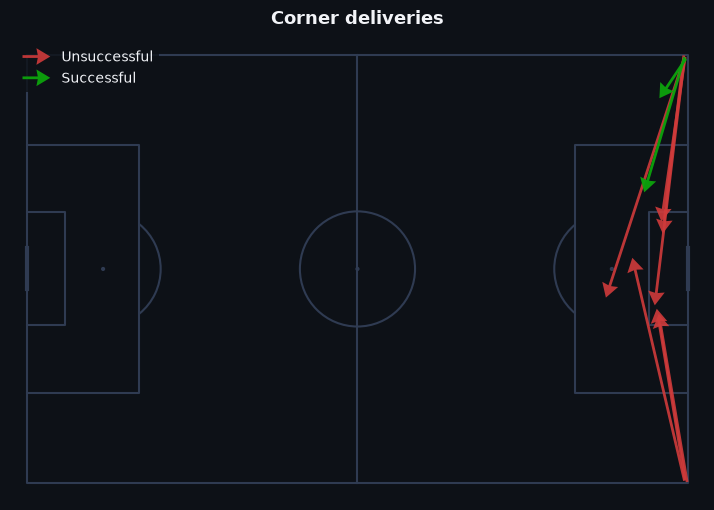

In [35]:
import matplotlib.pyplot as plt

from wa_setpieces.viz.plots import (
    plot_aerial_duel_win_rate,
    plot_defensive_routine_bars,
    plot_delivery_map,
    plot_routine_clusters,
)

fig, ax = plot_delivery_map(corner_deliveries, title="Corner deliveries")
plt.show()


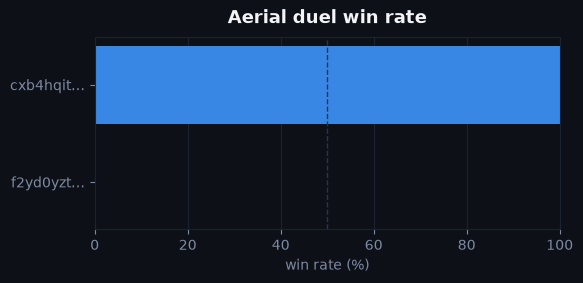

In [36]:
fig, ax = plot_aerial_duel_win_rate(aerial_team_summary, title="Aerial duel win rate")
plt.show()


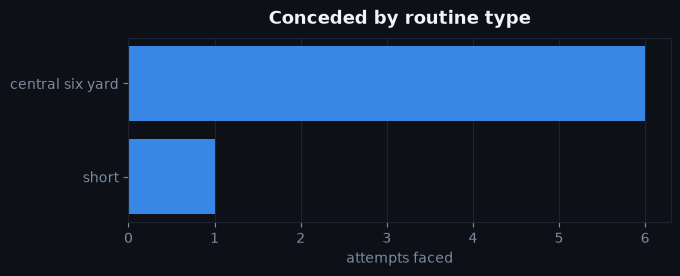

In [37]:
fig, ax = plot_defensive_routine_bars(
    workflow.defensive_routine_summary, team_id=opponent, title="Conceded by routine type"
)
plt.show()


## 15. Exporting

Any table this package produces can be saved to CSV or Excel with
`save_table`/`save_tables` (Excel needs the `xlsx` extra). The
`workflow`/`report` CLI subcommands do the same for every table in one
`SetPieceWorkflow`, with no extra flags needed.


In [38]:
from wa_setpieces import save_table, save_tables

save_table(report, OUTPUT_DIR / "corner_report.csv")
save_table(report, OUTPUT_DIR / "corner_report.xlsx")

workflow_tables = {
    field: getattr(workflow, field)
    for field in workflow.__dataclass_fields__
    if isinstance(getattr(workflow, field), pd.DataFrame)
}
save_tables(workflow_tables, OUTPUT_DIR / "workflow_tables", fmt="csv")

sorted(p.name for p in (OUTPUT_DIR / "workflow_tables").glob("*.csv"))


['added_value.csv',
 'aerial_duel_player_summary.csv',
 'aerial_duel_team_summary.csv',
 'defensive_routine_summary.csv',
 'defensive_summary.csv',
 'defensive_zone_summary.csv',
 'deliveries.csv',
 'first_contacts.csv',
 'player_counts.csv',
 'player_rating.csv',
 'report.csv',
 'retention.csv',
 'routine_clusters.csv',
 'routine_summary.csv',
 'routine_taker_profiles.csv',
 'routine_target_matrix.csv',
 'routine_team_profiles.csv',
 'routines.csv',
 'second_phases.csv',
 'summary.csv',
 'team_counts.csv',
 'team_rating.csv']

## 16. Command line

Everything above is also available without writing any Python, via the
`wa-setpieces` CLI installed alongside the package:

```bash
wa-setpieces match.json
wa-setpieces match.json --csv summary.csv
wa-setpieces workflow match.json --type corner --model league-model.npz --output tables/
wa-setpieces report match.json --type corner --model league-model.npz --output report.html
```

See the [README](../README.md) for the full function list, the
[quickstart](../docs/source/quickstart.rst)/[user guide](../docs/source/user_guide/index.rst)
docs pages for narrative walkthroughs, and the
[example gallery](../docs/source/gallery/index.rst) for more plotting
recipes.
